# Full Pipeline - VAE Healer + ResNet Expert
Integrate trained Stage A and Stage B modules into one self-healing inference pipeline.

In [2]:
import time
import sys
from pathlib import Path

import yaml
import torch
import matplotlib.pyplot as plt

# Ensure imports from project root work regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import get_dataloaders, NoiseInjector
from src.conv_vae import ConvVAE
from src.classifier import get_classifier
from src.pipeline import SelfHealingPipeline

In [3]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

models_dir = (project_root / 'models').resolve()
vae_path = models_dir / 'conv_vae_best.pth'
classifier_path = models_dir / 'resnet_classifier.pth'
data_root = (project_root / config['dataset']['root']).resolve()

device = config['training']['device'] if torch.cuda.is_available() else 'cpu'
vae = ConvVAE(latent_dim=config['vae']['latent_dim']).to(device)
classifier = get_classifier(num_classes=config['dataset']['num_classes'], pretrained=False).to(device)

vae.load_state_dict(torch.load(vae_path, map_location=device))
classifier.load_state_dict(torch.load(classifier_path, map_location=device))
vae.eval()
classifier.eval()
print(f'Using data root: {data_root}')

C:\Users\Akash\AppData\Local\Temp\ipykernel_7280\2443349838.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae.load_state_dict(torch.load(vae_path, map_location=device

Using data root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw


C:\Users\Akash\AppData\Local\Temp\ipykernel_7280\2443349838.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load(classifier_path, map_l

In [4]:
pipeline = SelfHealingPipeline(vae=vae, classifier=classifier).to(device)
pipeline

SelfHealingPipeline(
  (vae): ConvVAE(
    (encoder): ConvEncoder(
      (features): Sequential(
        (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.2, inplace=True)
        (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): LeakyReLU(negative_slope=0.2, inplace=True)
        (9): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (10): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (11): LeakyReLU(negative_slo

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

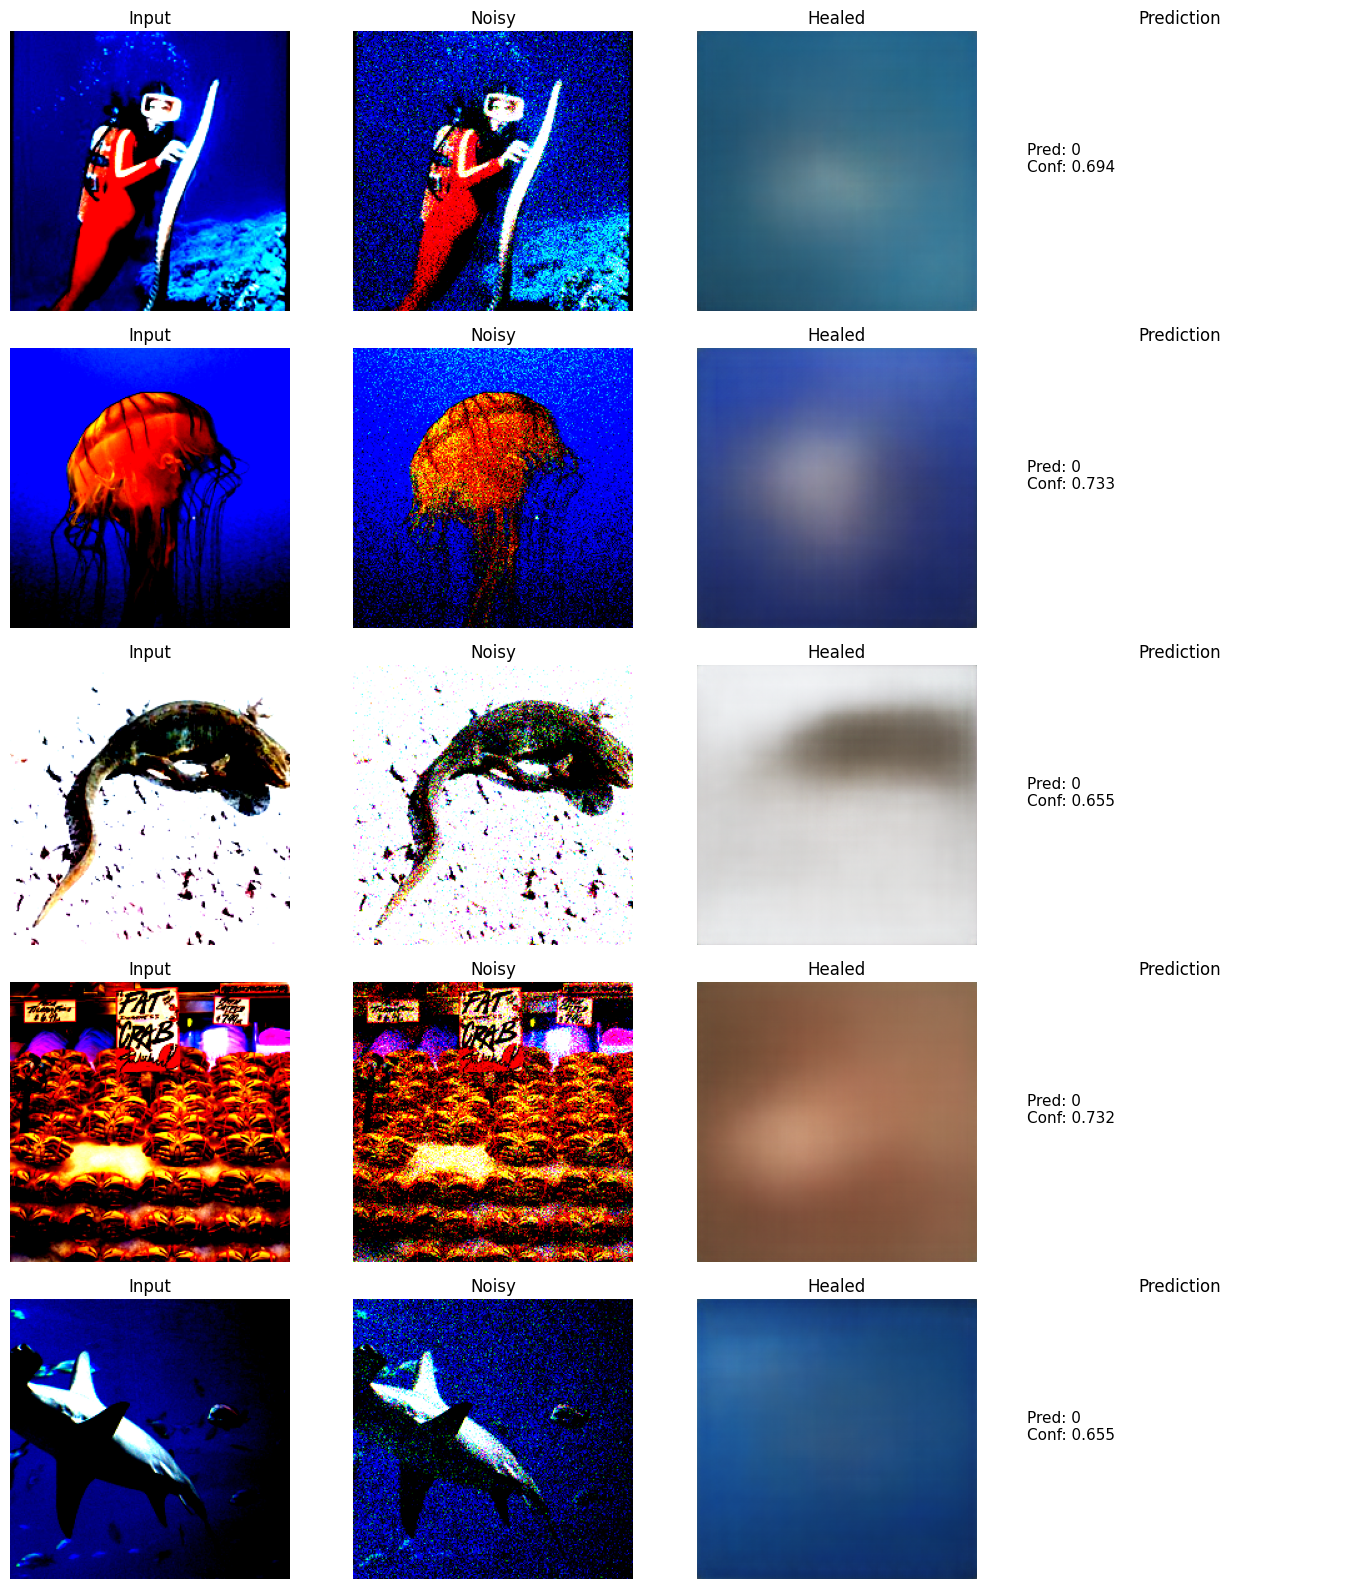

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    root=str(data_root),
    image_size=config['dataset']['image_size'],
    batch_size=8,
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=False
)

injector = NoiseInjector()
images, labels = next(iter(test_loader))
images = images[:5].to(device)
noisy = torch.stack([injector.add_gaussian_noise(img, std=0.5) for img in images])
preds, confs, healed = pipeline(noisy)

fig, axes = plt.subplots(5, 4, figsize=(14, 16))
for i in range(5):
    axes[i, 0].imshow(images[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 0].set_title('Input')
    axes[i, 1].imshow(noisy[i].detach().cpu().permute(1, 2, 0).numpy(), vmin=-2, vmax=2)
    axes[i, 1].set_title('Noisy')
    axes[i, 2].imshow(healed[i].detach().cpu().permute(1, 2, 0).numpy())
    axes[i, 2].set_title('Healed')
    axes[i, 3].text(0.05, 0.5, f'Pred: {int(preds[i])}\nConf: {float(confs[i]):.3f}', fontsize=11)
    axes[i, 3].set_title('Prediction')
    for j in range(4):
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [6]:
warmup = noisy[:1]
_ = pipeline(warmup)

runs = 30
start = time.perf_counter()
for _ in range(runs):
    _ = pipeline(warmup)
elapsed_ms = (time.perf_counter() - start) * 1000 / runs
print(f'Average end-to-end inference time: {elapsed_ms:.2f} ms / sample')

Average end-to-end inference time: 9.66 ms / sample


In [7]:
batch = noisy
with torch.no_grad():
    pred_b, conf_b, healed_b = pipeline(batch)

print('Batch size:', batch.size(0))
print('Predictions:', pred_b.tolist())
print('Confidences:', [round(float(c), 4) for c in conf_b])
print('Healed batch shape:', tuple(healed_b.shape))

Batch size: 5
Predictions: [0, 0, 0, 0, 0]
Confidences: [0.7437, 0.6338, 0.7099, 0.7492, 0.6635]
Healed batch shape: (5, 3, 224, 224)


## Summary
The integrated pipeline successfully denoises corrupted inputs and produces classifier predictions with measurable end-to-end latency.